# Digital signal processing. Lab7

In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('fivethirtyeight')

## Task1

Реализовать сигнал с единичными выбросами. Реализовать метод для исключения выбросов в сигнале через порог стандартного отклонения. Сравнить данный метод фильтрации с медианным фильтром. Представить очищенный сигнал.

In [3]:
def median_filter(signal, window_width, percent_threshold=90, k_pre=15):
    processed_signal = signal.copy()
    
    def _preprocess():
        active_spikes = processed_signal[processed_signal > 0]
        if len(active_spikes) > 0:
            threshold = np.percentile(active_spikes, percent_threshold)
            processed_signal[processed_signal > threshold] = 0.0
            
        # Рассматриваем локальное окно вокруг каждой точки и берем среднее,
        # чтобы убрать 0.
        envelope_signal = np.zeros_like(processed_signal)
        for t in range(len(processed_signal)):
            left = max(0, t - k_pre)
            right = min(len(processed_signal), t + k_pre + 1)
            envelope_signal[t] = np.mean(processed_signal[left:right])
            
        return envelope_signal
        
    preprocessed_signal = _preprocess()
    
    result = np.zeros_like(preprocessed_signal)
    k = (window_width - 1) // 2
    
    for t in range(len(preprocessed_signal)):
        left = max(0, t - k)
        right = min(len(preprocessed_signal), t + k + 1)
        result[t] = np.median(preprocessed_signal[left:right])
    
    return result

In [4]:
def std_filter(signal, sigma_coeff=3):
    
    mean = np.mean(signal)
    std = np.std(signal)
    threshold = mean + sigma_coeff * std
    
    upper_bound = mean + sigma_coeff * std
    lower_bound = mean - sigma_coeff * std

    outliers_mask = (signal > upper_bound) | (signal < lower_bound)
    
    filtered_signal = signal.copy()
    filtered_signal[filtered_signal > threshold] = mean
    
    return filtered_signal, upper_bound, lower_bound

In [5]:
np.random.seed(42)
N = 2000
t_vals = np.linspace(0, 10, N)

clean_signal = np.sin(2 * np.pi * 0.5 * t_vals)

noise = np.random.normal(0, 0.1, N)
noisy_signal = clean_signal + noise

spike_indices = np.random.choice(N, 50, replace=False)
noisy_signal[spike_indices] += np.random.uniform(2, 5, 50) 

sigma_coeff = 3

std_filtred_signal, std_upper_bound, std_lower_bound = std_filter(noisy_signal, sigma_coeff=sigma_coeff)
median_filtered_signal = median_filter(noisy_signal, window_width=31, k_pre=25)

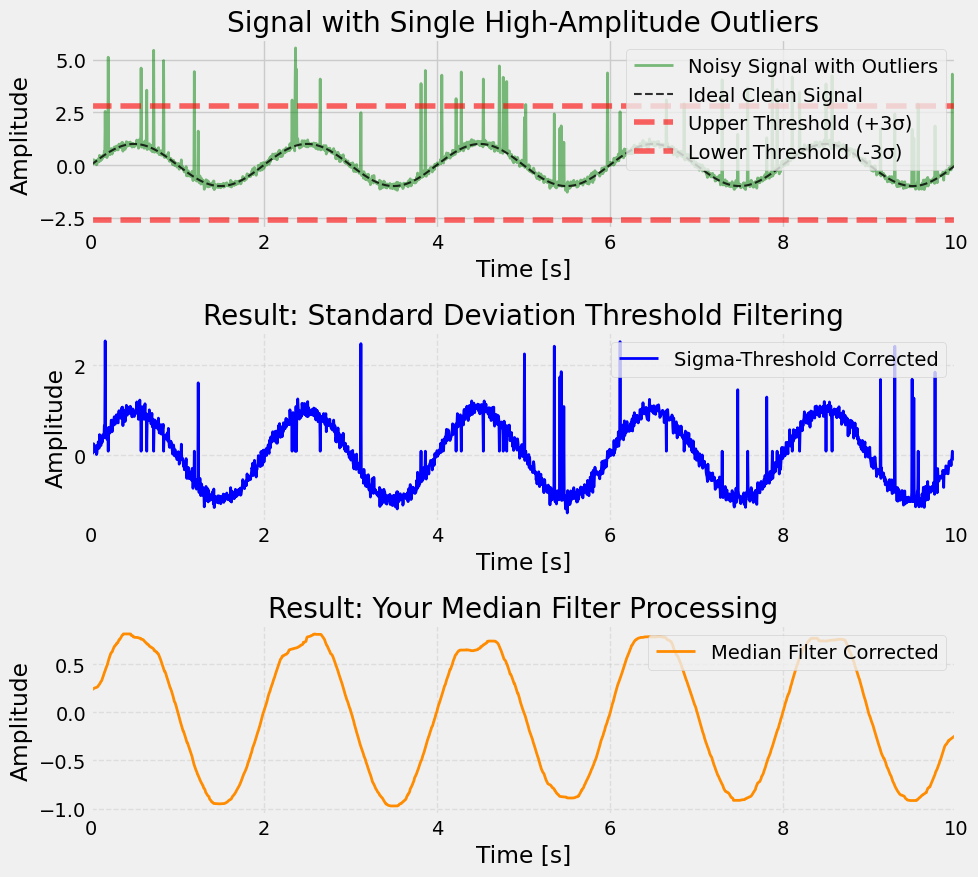

In [6]:
plt.figure(figsize=(10, 9))


plt.subplot(3, 1, 1)
plt.plot(t_vals, noisy_signal, 'g-', alpha=0.5, linewidth=2, label='Noisy Signal with Outliers')
plt.plot(t_vals, clean_signal, 'k--', linewidth=1.5, alpha=0.8, label='Ideal Clean Signal')
# Рисуем пунктирные линии порогов 3σ для наглядности
plt.axhline(std_upper_bound, color='r',linestyle='--', alpha=0.6, label=f'Upper Threshold (+{sigma_coeff}σ)')
plt.axhline(std_lower_bound, color='r',linestyle='--', alpha=0.6, label=f'Lower Threshold (-{sigma_coeff}σ)')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title('Signal with Single High-Amplitude Outliers')
plt.xlim(0, 10)
plt.legend(loc='upper right')

plt.subplot(3, 1, 2)
plt.plot(t_vals, std_filtred_signal, 'b-', linewidth=2, label='Sigma-Threshold Corrected')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title('Result: Standard Deviation Threshold Filtering')
plt.xlim(0, 10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

plt.subplot(3, 1, 3)
plt.plot(t_vals, median_filtered_signal, color='darkorange', linestyle='-', linewidth=2, label='Median Filter Corrected', )
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title('Result: Your Median Filter Processing')
plt.xlim(0, 10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()


## Task2
Реализовать сигнал, который содержит области с высоким уровнем шума. Это может быть сделано путем добавления случайного шума к основному сигналу в определенных интервалах времени. Напишите метод для очистки сигнала с помощью оконного скользящего среднеквадратичного отклонения (Outlier time windows via sliding RMS).

$$
\mathrm{RMS}_n = \sqrt{\frac{1}{M}\sum_{k=n-m}^{n+m} x[k]^2}.
$$



Алгоритм выявления шумных участков:

1. Вычислить $\mathrm{RMS}_n$ для всех $n$, где окно укладывается в сигнал.
2. Оценить порог $T_{\text{rms}}$, например, как $T_{\text{rms}} = k_{\text{rms}} \cdot \text{median}(\mathrm{RMS}_n)$, где $k_{\text{rms}}$ — коэффициент (типично $1.5–3$).
3. Найти все интервалы, где $\mathrm{RMS}_n > T_{\text{rms}}$, и объединить их в области временных окон с повышенным шумом.
4. Заменить значения в этих интервалах:
   - интерполяцией между соседними «нормальными» участками,
   - фильтрацией или заменой на среднее/медианное значение по окну.

In [7]:
def calculate_RMS(signal, window_width):
    result = np.zeros_like(signal, dtype=float)
    
    if window_width % 2 == 0:
        window_width += 1
    
    k = (window_width - 1) // 2
    N = len(signal)
    
    for t in range(N):
        left = max(0, t - k)
        right = min(N, t + k + 1)
        
        window_data = signal[left:right]
        window_centered = window_data - np.mean(window_data)
        
        rms_value = np.sqrt(np.mean(window_centered ** 2))
        result[t] = rms_value
        
    return result

In [8]:
N = 2000
t_vals = np.linspace(0, 10, N)

clean_signal = np.sin(2 * np.pi * 0.3 * t_vals) * 2

base_noise = np.random.normal(0, 0.1, N)
noisy_signal = clean_signal + base_noise

mask_burst_1 = (t_vals >= 2.5) & (t_vals <= 4.0)
noisy_signal[mask_burst_1] += np.random.normal(0, 1.5, np.sum(mask_burst_1))

mask_burst_2 = (t_vals >= 7.0) & (t_vals <= 8.5)
noisy_signal[mask_burst_2] += np.random.normal(0, 2.0, np.sum(mask_burst_2))


rms_profile = calculate_RMS(noisy_signal, window_width=16)


# 2: Оценка порога через медиану
k_rms = 2.5
rms_threshold = k_rms * np.median(rms_profile)


# 3: Находим интервалы аномального шума
bad_windows_mask = rms_profile > rms_threshold


# 4: Замена значений интерполяцией между нормальными участками
filtered_signal = noisy_signal.copy()

# Индексы «хороших» (нормальных) точек сигнала
good_indices = np.where(~bad_windows_mask)[0]
# Индексы зашумленных точек, которые нужно заменить
bad_indices = np.where(bad_windows_mask)[0]

if len(bad_indices) > 0 and len(good_indices) > 0:
    filtered_signal[bad_indices] = np.interp(t_vals[bad_indices], t_vals[good_indices], noisy_signal[good_indices])

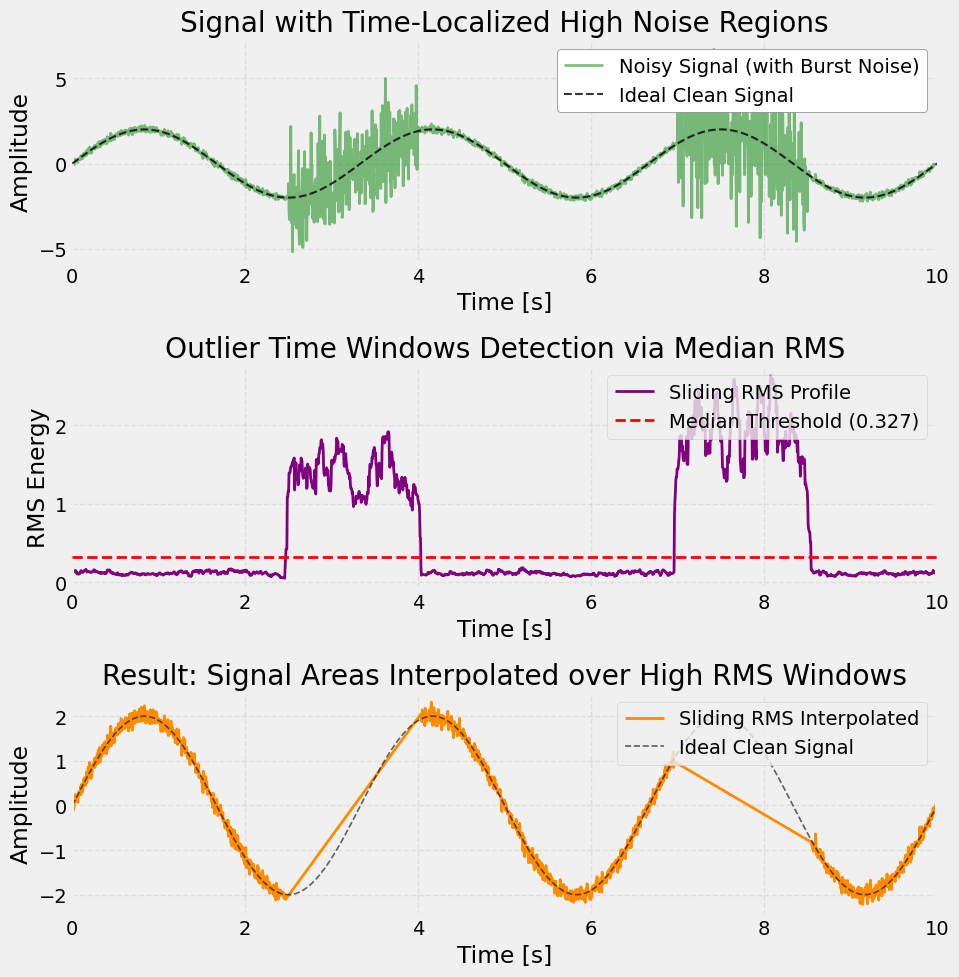

In [9]:
plt.figure(figsize=(10, 10))

plt.subplot(3, 1, 1)
plt.plot(t_vals, noisy_signal, 'g-', alpha=0.5, linewidth=2, label='Noisy Signal (with Burst Noise)', zorder=2)
plt.plot(t_vals, clean_signal, 'k--', linewidth=1.5, alpha=0.8, label='Ideal Clean Signal', zorder=3)
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title('Signal with Time-Localized High Noise Regions')
plt.xlim(0, 10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right', framealpha=1.0, facecolor='white', edgecolor='gray')

plt.subplot(3, 1, 2)
plt.plot(t_vals, rms_profile, color='purple', linewidth=2, label='Sliding RMS Profile')
plt.axhline(rms_threshold, color='red', linestyle='--', linewidth=2, label=f'Median Threshold ({rms_threshold:.3f})', zorder=3)
plt.xlabel('Time [s]')
plt.ylabel('RMS Energy')
plt.title('Outlier Time Windows Detection via Median RMS')
plt.xlim(0, 10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

plt.subplot(3, 1, 3)
plt.plot(t_vals, filtered_signal, color='darkorange', linewidth=2, label='Sliding RMS Interpolated')
plt.plot(t_vals, clean_signal, 'k--', linewidth=1.2, alpha=0.6, label='Ideal Clean Signal')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title('Result: Signal Areas Interpolated over High RMS Windows')
plt.xlim(0, 10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

## Task3. Метод спектральной интерполяции сигналов.  

Данный метод позволяет восстановить часть сигнала, которая была потеряна или удалена.

Длина окон должна совпадать

Алгоритм реализации метода:
1) Для реализации сигнала рассмотрите сигнал из предыдущего пункта 2, в котором Вы уже удалили часть сигнала с помощью скользящего среднеквадратичного отклонения. Необходимо восстановить потерянную часть сигнала с помощью спектральной интерполяции.
2) задать размер окна по временной области для которых будет определяться спектр. Размер окон для правой и левой части должны совпадать.
3) определить спектр сигнала до разрыва и после разрыва.
4) осуществить усреднение спектров сигналов в правой и левой области.
5) с помощью обратного преобразования Фурье восстановить утерянную часть сигнала.
6) сшить границы с помощью линейной интерполяции.

In [10]:
# 1: Находим точные границы ПЕРВОГО изолированного разрыва
bad_indices = np.where(bad_windows_mask)[0]

# Находим, где прерывается последовательность индексов, чтобы взять только первый кусок шума
diffs = np.diff(bad_indices)
split_points = np.where(diffs > 1)[0]

idx_start = bad_indices[0]
if len(split_points) > 0:
    idx_end = bad_indices[split_points[0]]  # Конец первой пачки шума
else:
    idx_end = bad_indices[-1]

len_gap = idx_end - idx_start + 1  # Длина утерянной части

# Создаем копию сигнала, где поврежденная область физически «удалена» (обнулена)
gap_signal = noisy_signal.copy()
gap_signal[idx_start:idx_end+1] = 0.0


# 2: Задаем симметричные окна слева и справа (Длина окон M совпадает) 
M = len_gap 
left_window_data = gap_signal[idx_start - M : idx_start]
right_window_data = gap_signal[idx_end + 1 : idx_end + 1 + M]


# 3: Определяем комплексный спектр до и после разрыва 
fft_left = np.fft.fft(left_window_data)
fft_right = np.fft.fft(right_window_data)


# 4: Усредняем спектры (сохраняем и амплитуду, и фазу синуса) 
fft_averaged = (fft_left + fft_right) / 2.0


# 5: Восстанавливаем утерянный кусок через Обратное БПФ 
reconstructed_gap = - np.fft.ifft(fft_averaged).real


# 6: Сшиваем границы спектрального куска с оригинальным сигналом 
spectral_interp_signal = gap_signal.copy()
spectral_interp_signal[idx_start:idx_end+1] = reconstructed_gap

# Линейное сглаживание швов на стыках (по 5 точек с каждого края)
fade_len = 5
for i in range(fade_len):
    w_left = i / fade_len
    idx_l = idx_start + i
    spectral_interp_signal[idx_l] = (1 - w_left) * gap_signal[idx_start - 1] + w_left * spectral_interp_signal[idx_l]
    
    w_right = i / fade_len
    idx_r = idx_end - i
    spectral_interp_signal[idx_r] = (1 - w_right) * gap_signal[idx_end + 1] + w_right * spectral_interp_signal[idx_r]

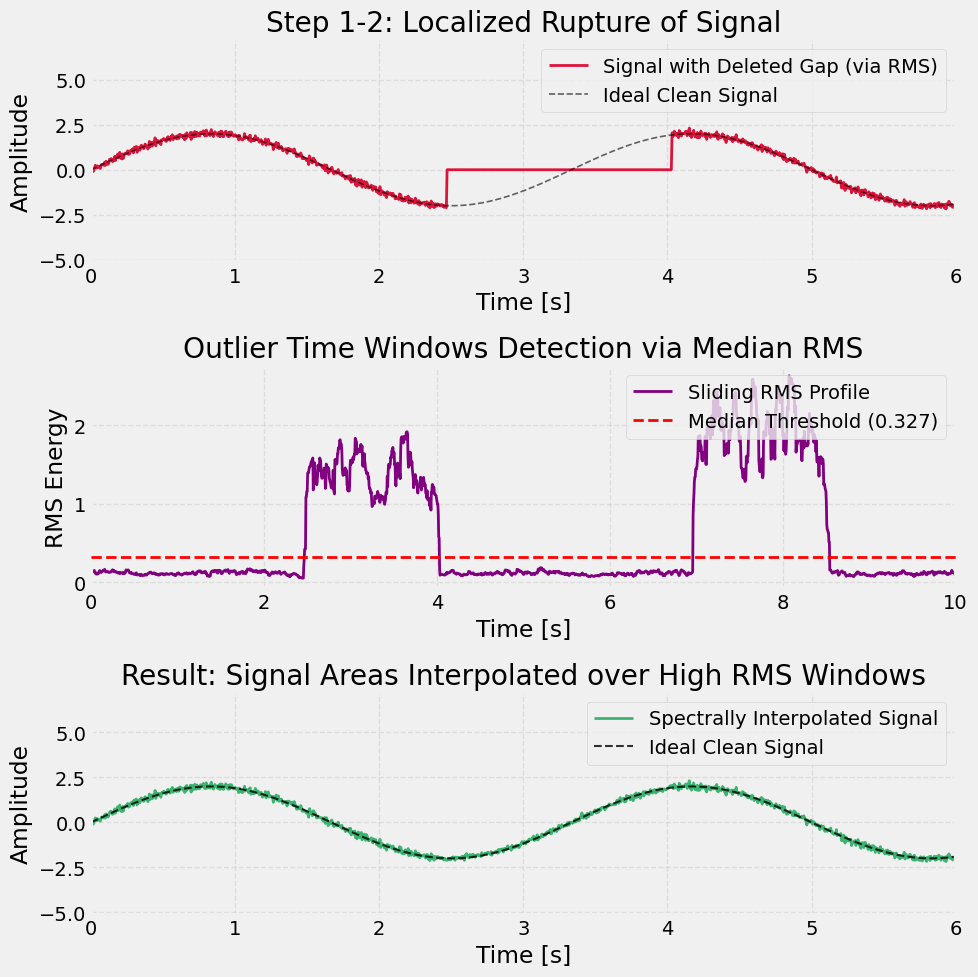

In [11]:
plt.figure(figsize=(10, 10))

plt.subplot(3, 1, 1)
plt.plot(t_vals, gap_signal, color='crimson', linewidth=2, label='Signal with Deleted Gap (via RMS)')
plt.plot(t_vals, clean_signal, 'k--', linewidth=1.2, alpha=0.6, label='Ideal Clean Signal')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title('Step 1-2: Localized Rupture of Signal')
plt.xlim(0, 6)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

plt.subplot(3, 1, 2)
plt.plot(t_vals, rms_profile, color='purple', linewidth=2, label='Sliding RMS Profile')
plt.axhline(rms_threshold, color='red', linestyle='--', linewidth=2, label=f'Median Threshold ({rms_threshold:.3f})', zorder=3)
plt.xlabel('Time [s]')
plt.ylabel('RMS Energy')
plt.title('Outlier Time Windows Detection via Median RMS')
plt.xlim(0, 10) # Шкала до 10 секунд!
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

plt.subplot(3, 1, 3)
plt.plot(t_vals, spectral_interp_signal, color='mediumseagreen', linewidth=2, label='Spectrally Interpolated Signal')
plt.plot(t_vals, clean_signal, 'k--', linewidth=1.5, alpha=0.8, label='Ideal Clean Signal')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title('Result: Signal Areas Interpolated over High RMS Windows')
plt.xlim(0, 6)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

## Task4. Алгоритм понижения/повышения дискретности сигнала в N раз.

Понижение дискретности сигнала можно осуществить двумя методами:
- (a) уменьшением числа точек в сигнале в N раз (неправильный). 
**Замечание:** для увеличения дискретности сигнала данным способом можно воспользоваться и он будет правильным.
- (b) уменьшением дискретности сигнала в N раз (правильный) с помощью определения новой частоты Найквиста, которая будет соответствовать новой дискретности сигнала.


> **Замечание:** Понижение дискретности сигнала осуществляется в три этапа, рис. 6. В качестве исходного сигнала можно выбрать сигнал косинуса с двумя частотами, например, 50 и 100 Гц.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt


fs = 2000 
dt4 = 1.0 / fs
t4 = np.arange(0, 0.5, dt4)

f_1 = 50.0
f_2 = 150.0
f_3 = 450.0

w_1 = 2 * np.pi * f_1
w_2 = 2 * np.pi * f_2
w_3 = 2 * np.pi * f_3

sig4_func = lambda t : np.cos(w_1 * t) + np.cos(w_2 * t) + np.cos(w_3 * t)
sig4 = sig4_func(t4)

N = 4 
fs_new = fs / N
nyq_new = fs_new / 2

def get_spectrum(signal, sampling_rate):
    n_samples = len(signal)
    freqs = np.fft.fftfreq(n_samples, 1/sampling_rate)[:n_samples//2]
    fft_vals = np.abs(np.fft.fft(signal))[:n_samples//2] * 2 / n_samples
    return freqs, fft_vals


#(а) : Простое прореживание (массив уменьшается, алиасинг появляется)
sig_down_wrong = sig4[::N]
t_down = t4[::N]

#(b) : Фильтр Найквиста + прореживание
b_down, a_down = butter(8, nyq_new / (fs / 2), btype='low')
sig_lp = filtfilt(b_down, a_down, sig4)
sig_down_right = sig_lp[::N]

sig_up_zeroed = np.zeros(len(sig_down_right) * N)
sig_up_zeroed[::N] = sig_down_right

b_up, a_up = butter(8, nyq_new / (fs / 2), btype='low')
sig_upsampled = filtfilt(b_up, a_up, sig_up_zeroed) * N

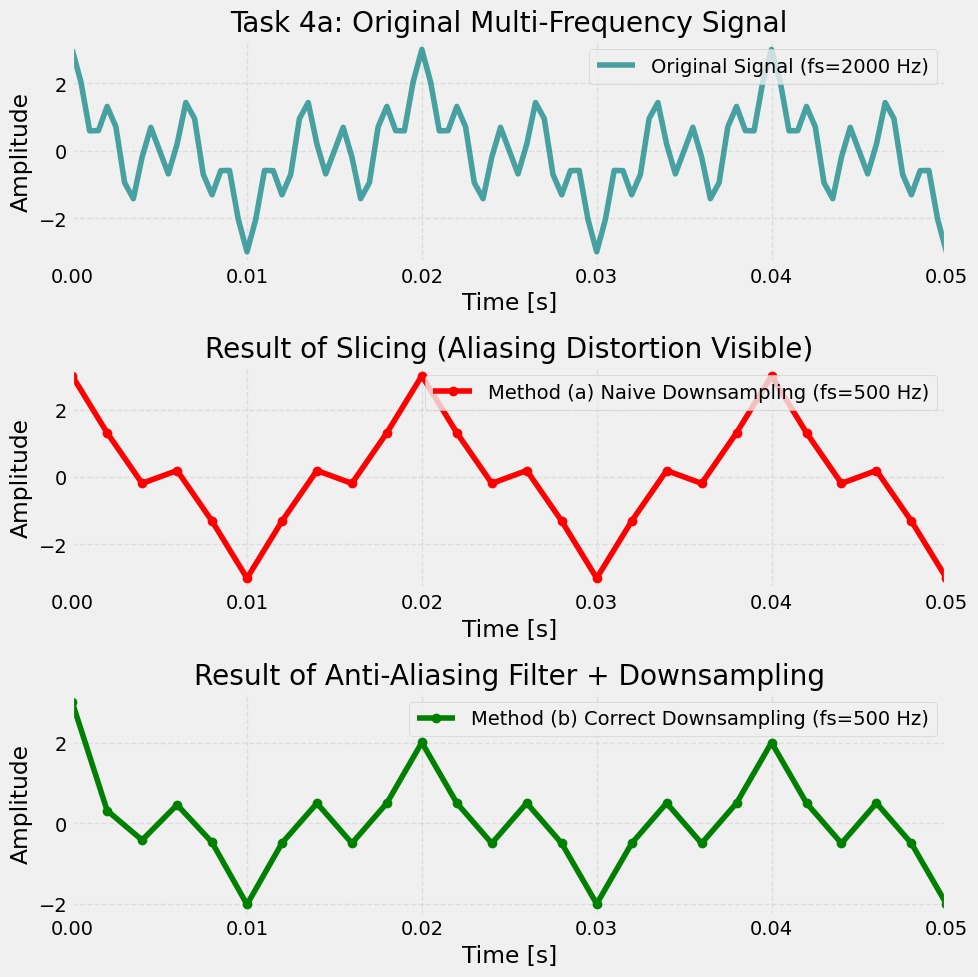

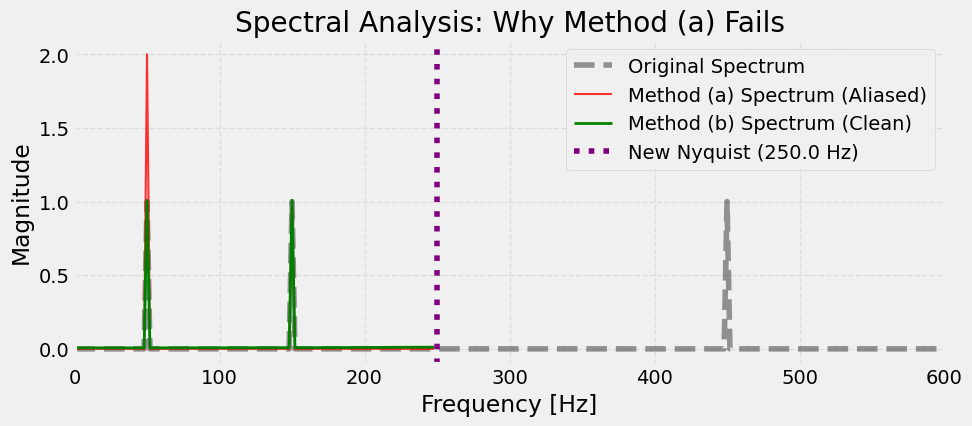

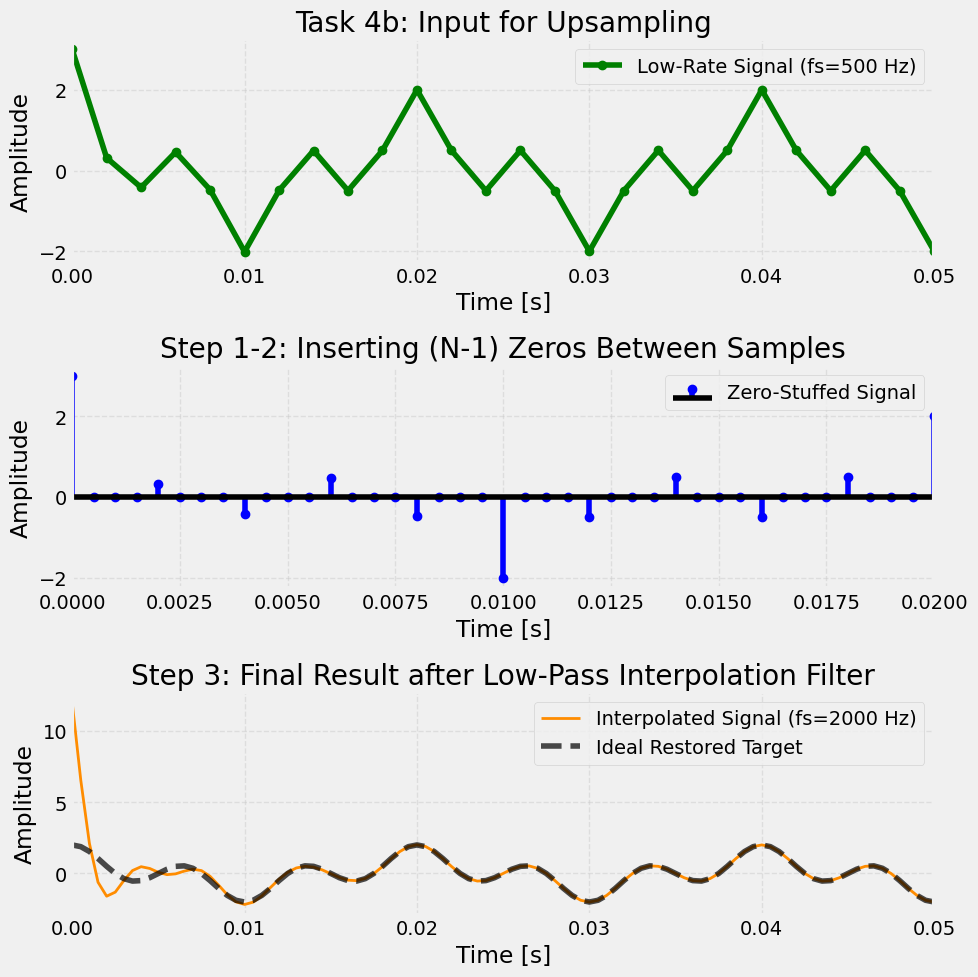

In [13]:
plt.figure(figsize=(10, 10))

plt.subplot(3, 1, 1)
plt.plot(t4, sig4, color='teal', alpha=0.7, label=f'Original Signal (fs={fs} Hz)')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title('Task 4a: Original Multi-Frequency Signal')
plt.xlim(0, 0.05) # Меньше окно, так как частоты стали выше
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

plt.subplot(3, 1, 2)
plt.plot(t_down, sig_down_wrong, 'ro-', label=f'Method (a) Naive Downsampling (fs={int(fs_new)} Hz)')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title('Result of Slicing (Aliasing Distortion Visible)')
plt.xlim(0, 0.05)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

plt.subplot(3, 1, 3)
plt.plot(t_down, sig_down_right, 'go-', label=f'Method (b) Correct Downsampling (fs={int(fs_new)} Hz)')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title('Result of Anti-Aliasing Filter + Downsampling')
plt.xlim(0, 0.05)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 4))
f_orig, spec_orig = get_spectrum(sig4, fs)
f_wrong, spec_wrong = get_spectrum(sig_down_wrong, fs_new)
f_right, spec_right = get_spectrum(sig_down_right, fs_new)

plt.plot(f_orig, spec_orig, 'k--', alpha=0.4, label='Original Spectrum')
plt.plot(f_wrong, spec_wrong, color='red', alpha=0.8, linewidth=1.5, label='Method (a) Spectrum (Aliased)')
plt.plot(f_right, spec_right, color='green', linewidth=2, label='Method (b) Spectrum (Clean)')
plt.axvline(nyq_new, color='purple', linestyle=':', label=f'New Nyquist ({nyq_new} Hz)')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.title('Spectral Analysis: Why Method (a) Fails')
plt.xlim(0, 600)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.show()



plt.figure(figsize=(10, 10))

plt.subplot(3, 1, 1)
plt.plot(t_down, sig_down_right, 'go-', label=f'Low-Rate Signal (fs={int(fs_new)} Hz)')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title('Task 4b: Input for Upsampling')
plt.xlim(0, 0.05)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

plt.subplot(3, 1, 2)
plt.stem(t4[:50], sig_up_zeroed[:50], linefmt='b-', markerfmt='bo', basefmt='k-', label='Zero-Stuffed Signal')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title('Step 1-2: Inserting (N-1) Zeros Between Samples')
plt.xlim(0, 0.02)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

plt.subplot(3, 1, 3)
plt.plot(t4, sig_upsampled, color='darkorange', linewidth=2, label=f'Interpolated Signal (fs={fs} Hz)')
# Идеальный целевой сигнал — это сумма 50 и 150 Гц (так как 450 Гц была срезана фильтром)
sig_ideal_restored = np.cos(w_1 * t4) + np.cos(w_2 * t4)
plt.plot(t4, sig_ideal_restored, 'k--', alpha=0.7, label='Ideal Restored Target')
plt.xlabel('Time [s]')
plt.ylabel('Amplitude')
plt.title('Step 3: Final Result after Low-Pass Interpolation Filter')
plt.xlim(0, 0.05)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

## Task5

В результате записи сигналов с 3-х различных датчиков были записаны данные с различной частотой дискретизации, рис 7 (a). Привести все сигналы к единой частоте дискретизации, как представлено на рис. 7 (b). В качестве сигналов можно выбрать три косинуса с различной частотой дискретизации, например 10, 35 и 80 Гц.


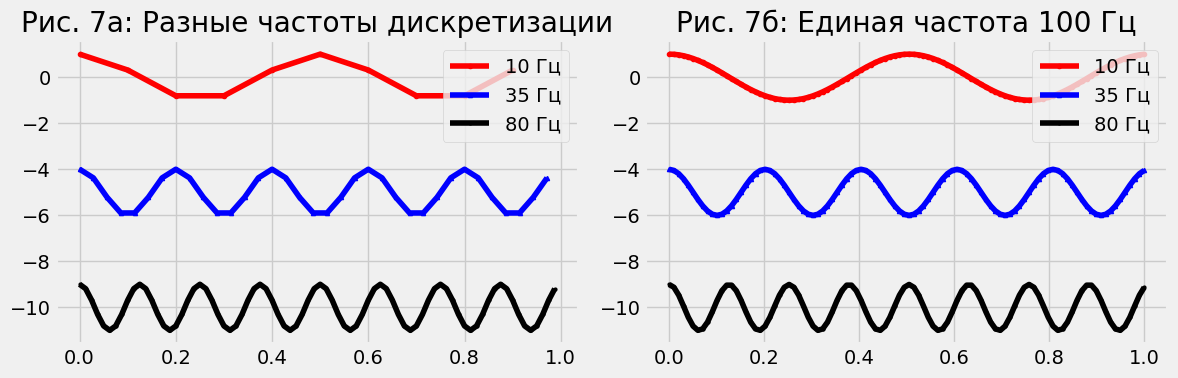

In [14]:
from scipy.signal import resample

fs1, fs2, fs3 = 10, 35, 80
duration = 1.0
target_fs = 100

t1 = np.arange(0, duration, 1/fs1)
t2_ = np.arange(0, duration, 1/fs2)
t3 = np.arange(0, duration, 1/fs3)

s1 = np.cos(2*np.pi*2*t1)
s2 = np.cos(2*np.pi*5*t2_) - 5
s3 = np.cos(2*np.pi*8*t3) - 10

target_len = int(duration * target_fs)
s1_r = resample(s1, target_len)
s2_r = resample(s2, target_len)
s3_r = resample(s3, target_len)
t_common = np.linspace(0, duration, target_len)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(t1, s1, 'ro-', ms=3, label=f'{fs1} Гц')
axes[0].plot(t2_, s2, 'b^-', ms=3, label=f'{fs2} Гц')
axes[0].plot(t3, s3, 'ko-', ms=2, label=f'{fs3} Гц')
axes[0].legend()
axes[0].set_title('Рис. 7а: Разные частоты дискретизации')
axes[1].plot(t_common, s1_r, 'ro-', ms=3, label=f'{fs1} Гц')
axes[1].plot(t_common, s2_r, 'b^-', ms=3, label=f'{fs2} Гц')
axes[1].plot(t_common, s3_r, 'ko-', ms=2, label=f'{fs3} Гц')
axes[1].legend()
axes[1].set_title(f'Рис. 7б: Единая частота {target_fs} Гц')
plt.tight_layout()
plt.show()